In [1]:
# Data Science mini project 2: Correlation and Regression Analysis between Age and Blood Pressure
# In this project we want to see if there is correlation between age and pressure, if yes how strong it is, and
# and if we can predict the age from the pressure

import numpy as np                 # Bring NumPy for numbers, arrays and random data
import matplotlib.pyplot as plt    # Bring MatplotLib for graphs (scatter plots, regression lines)
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

In [3]:
# Data generation

r = np.random
r.seed(42)

# Age (20-80)
age = r.randint(20, 80, 100)

# Pressure with Correlation + noise
blood_pressure = 0.8 * age + r.normal(0, 10, 100) + 80   # We generate data creates linear relationship (0.8 * age) that as age increases 
                                                         # blood pressure increases but there is noise . +80 is the baseline pressure.
                                                         # So, BP = 0.8*age + noise + baseline pressure.

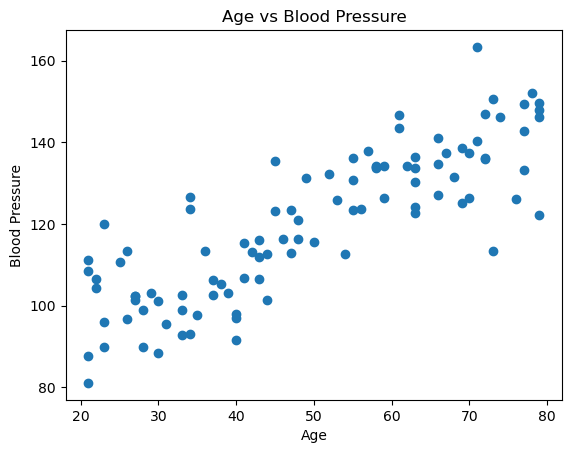

In [4]:
# Visualization
plt.scatter(age, blood_pressure)
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("Age vs Blood Pressure")
plt.show()

In [7]:
# Correlation (Pearson's correlation)
# Measures i) correlation coefficient, r = cov(X,Y)/(σX*σΥ) and ii) and the p-value (if correlation is significant).
# If r -> 1: strong positive correlation
# If p < 0.05: significant correlation
# Interpretation: r=0 (no correlation), 0<r<0.3 (weak), 0.3<r<0.5 (moderate), 0.5<r (strong)

corr, p_value = pearsonr(age, blood_pressure)

print("Correlation:", corr)
print("p_value:", p_value)

Correlation: 0.8396480135671773
p_value: 9.999259341823901e-28


In [9]:
# Linear Regression: y = ax + b
# With the Linear Regression we bring ML modeling.

x = age.reshape(-1, 1)        # Converts age to 2D because sklearn needs 2D input.
y = blood_pressure            # Target variable.

model = LinearRegression()    # Generate the model.
model.fit(x, y)               # Train the model. The model finds the best line and minimizes error. Mathematically: y = ax + b.

# Coefficients
a = model.coef_[0]            # Slope - how much blood pressure increases with each year of age.
b = model.intercept_          # Baseline when age = 0.

print("Slope (a):", a)        # The slope shows how much the pressure changes over age.
print("Intercept (b):", b)    # The intersept indicates the baseline.


Slope (a): 0.8481356087716322
Intercept (b): 77.93747614276452


In [11]:
# Prediction
predictions = model.predict(x)    # Calculates y^, ie. predicted blood pressure.

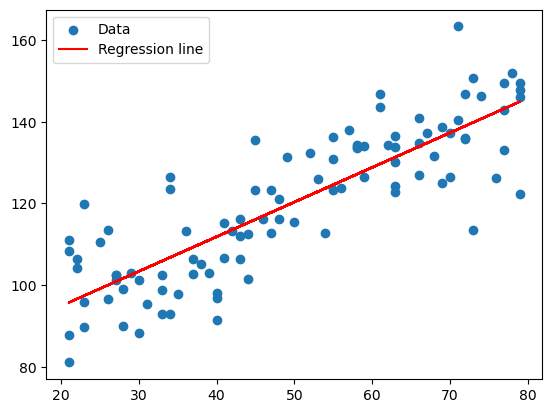

In [13]:
# Plot Regression line
plt.scatter(age, blood_pressure, label="Data")                        # Real data.
plt.plot(age, predictions, color="red", label="Regression line")      # The line of the model.
plt.legend()
plt.show()                                                            # How well does the line fit the data?

In [15]:
# R^2 Score (Coefficient of Determination):
# typically ranging from 0 to 1 and measures the proportion of variance in the dependent variable explained
# by the independent variables in a regression model. A higher score indicates a better fit, but it doesn't
# indicate causality, multicollinearity, or whether the model is inherently good or biased. So, it shows how
# well the model explains the data where: R^2 = 0 -> zero meaning, R^2 = 0.5 -> ok, R^2 > 0.8 -> very good.

r2 = model.score(x, y)
print("R^2:", r2)                          # R^2 -> 0: Bad interpretaion, R^2 -> 1 Perfect interpretation

R^2: 0.7050087866873064
